# Advertising Dataset - Detailed EDA Only

This notebook contains **only Exploratory Data Analysis (EDA)** for the dataset `Advertising.csv`.

## EDA goals
1. Load and inspect the dataset
2. Check shape, data types, and missing values
3. Compute descriptive statistics
4. Analyze distributions of all variables
5. Study correlations between variables
6. Visualize relationships with scatter plots
7. Detect potential outliers
8. Summarize key insights

> As requested, **each code cell is followed by a markdown cell explaining comments / meaning**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## Nhận xét / Ý nghĩa
Cell này import các thư viện cần thiết cho phần EDA:

- `pandas`: đọc và xử lý dữ liệu
- `numpy`: hỗ trợ tính toán
- `matplotlib`: vẽ biểu đồ

Ngoài ra, notebook thiết lập kích thước hình và bật lưới để các biểu đồ rõ ràng hơn khi báo cáo hoặc thuyết trình.


In [2]:
df = pd.read_csv("Advertising.csv")
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Nhận xét / Ý nghĩa
Cell này đọc dataset `Advertising.csv` và hiển thị 5 dòng đầu tiên.

Mục đích:
- kiểm tra file đã load đúng chưa
- xem các cột có trong dữ liệu
- quan sát sơ bộ giá trị của từng biến

Trong dataset này, ta thấy có 4 cột:
- `TV`
- `Radio`
- `Newspaper`
- `Sales`


In [3]:
df.shape


(200, 4)

## Nhận xét / Ý nghĩa
Cell này cho biết kích thước của dataset.
- **200 dòng**
- **4 cột**


In [4]:
df.columns.tolist()


['TV', 'Radio', 'Newspaper', 'Sales']

## Nhận xét / Ý nghĩa
Cell này liệt kê tên các cột trong dataset.

Ý nghĩa:
- xác nhận đúng các biến sẽ được phân tích
- giúp nhóm mô tả dataset rõ ràng trong report và slide


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Nhận xét / Ý nghĩa
Cell này kiểm tra:
- tên cột
- kiểu dữ liệu
- số lượng giá trị không bị thiếu

Ý nghĩa:
- nếu tất cả cột là số, dữ liệu rất phù hợp cho phân tích thống kê
- nếu không có giá trị bị thiếu, ta không cần xử lý missing values


In [6]:
df.isnull().sum()


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Nhận xét / Ý nghĩa
Cell này kiểm tra số lượng giá trị thiếu ở từng cột.

Không có giá trị nào bị thiếu 


In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


## Nhận xét / Ý nghĩa
Cell này tạo bảng thống kê mô tả cho từng biến, bao gồm:
- count
- mean
- std
- min
- 25%
- 50% (median)
- 75%
- max

Ý nghĩa:
- giúp hiểu phạm vi dữ liệu
- xem biến nào có độ dao động lớn
- hỗ trợ phát hiện dấu hiệu bất thường


In [8]:
df.skew(numeric_only=True)


TV          -0.069853
Radio        0.094175
Newspaper    0.894720
Sales       -0.073739
dtype: float64

## Nhận xét / Ý nghĩa
Cell này tính độ lệch phân phối (skewness) của từng biến.

Cách hiểu:
- gần 0: phân phối tương đối cân bằng
- dương: lệch phải
- âm: lệch trái

Thông thường trong dataset này:
- `TV`, `Radio`, `Sales` khá cân bằng
- `Newspaper` lệch phải rõ hơn


In [9]:
df.var(numeric_only=True)


TV           7370.949893
Radio         220.427743
Newspaper     474.308326
Sales          27.919517
dtype: float64

## Nhận xét / Ý nghĩa
Cell này tính phương sai của từng biến.

Ý nghĩa:
- phương sai lớn cho thấy biến dao động mạnh
- biến có phạm vi chi tiêu rộng hơn sẽ có phương sai lớn hơn

Trong bài này, `TV` thường có độ biến thiên lớn nhất.


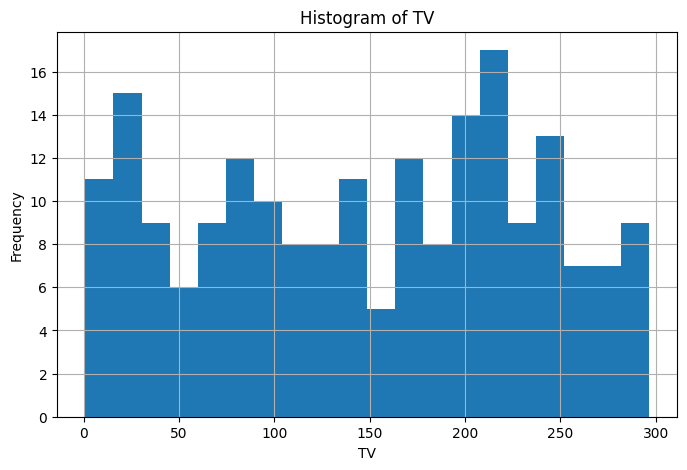

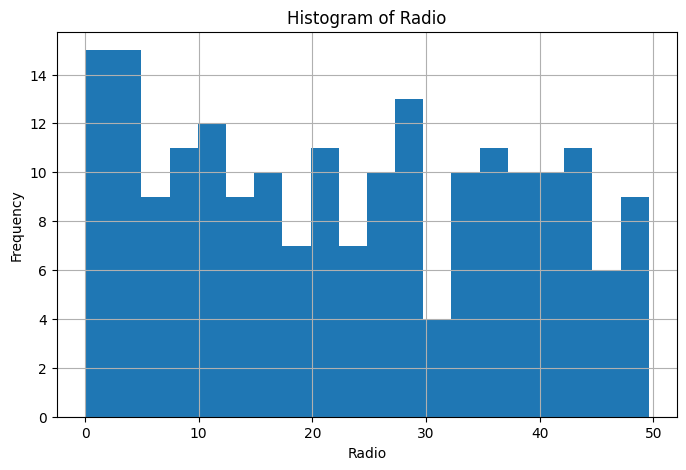

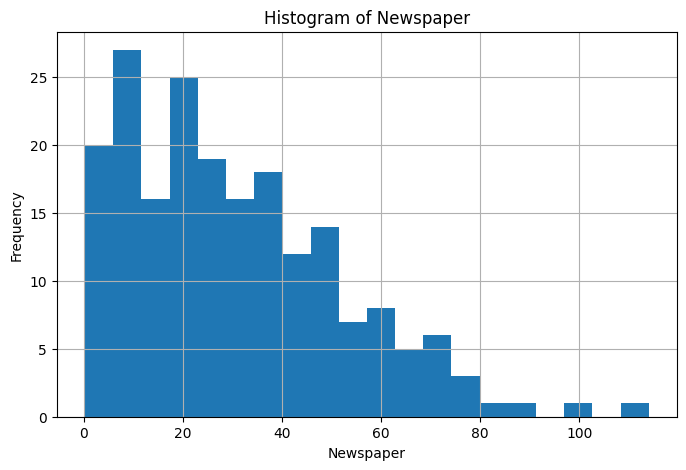

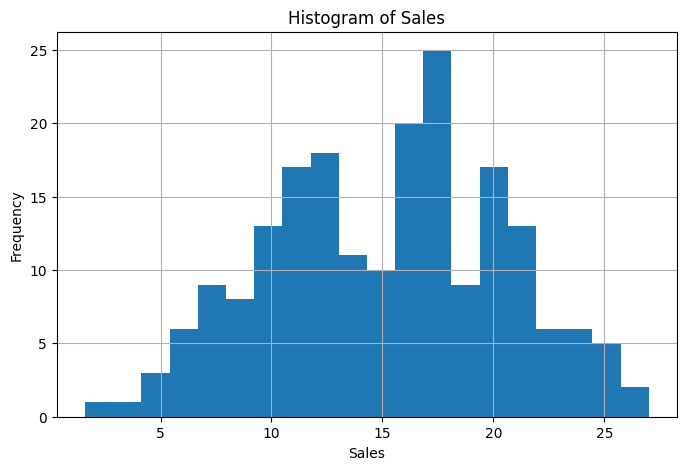

In [10]:
for col in df.columns:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## Nhận xét / Ý nghĩa
Các biểu đồ histogram giúp quan sát phân phối của từng biến.

Bạn có thể dùng các biểu đồ này để nhận xét:
- dữ liệu có trải đều hay không
- có bị lệch phân phối không
- có xuất hiện giá trị cực lớn / cực nhỏ không

Đây là bước rất quan trọng trong EDA trước khi xây dựng mô hình.


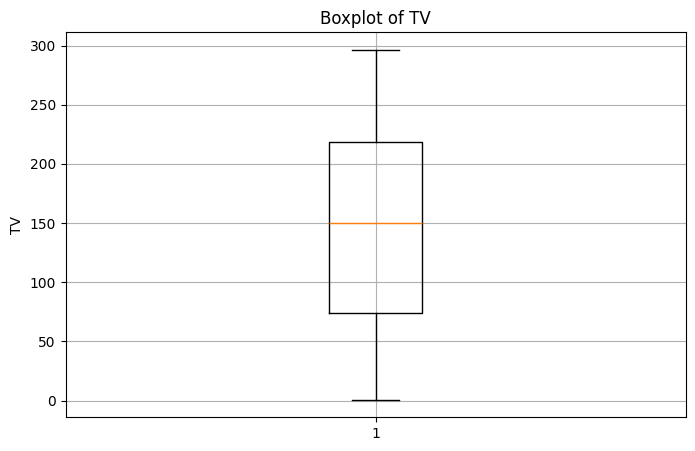

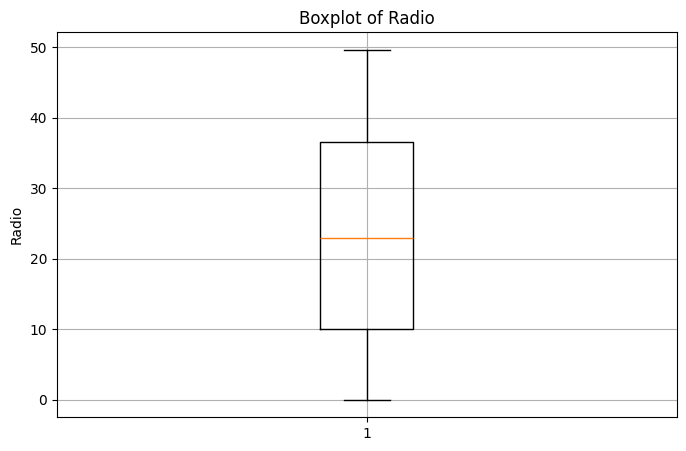

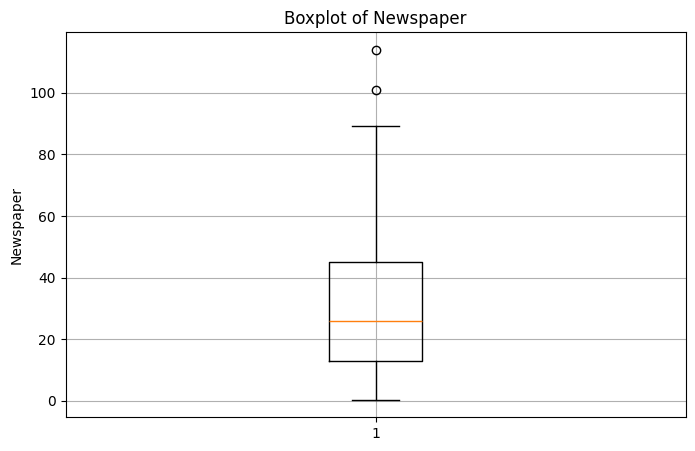

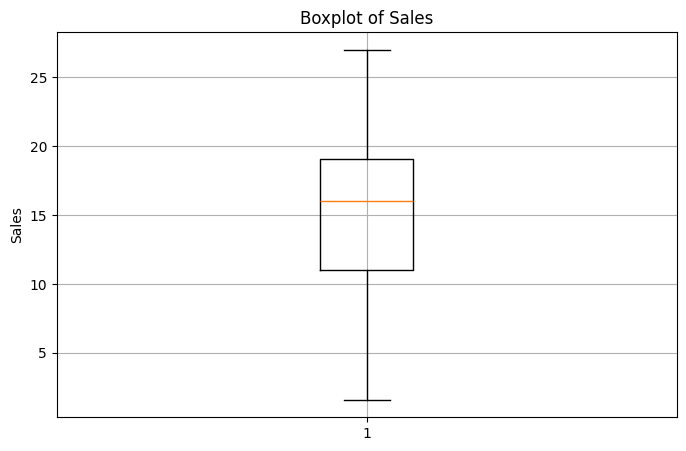

In [11]:
for col in df.columns:
    plt.figure()
    plt.boxplot(df[col], vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


## Nhận xét / Ý nghĩa
Các boxplot giúp phát hiện outliers và quan sát nhanh phân bố dữ liệu.

Ý nghĩa:
- đường giữa hộp là median
- hộp biểu diễn khoảng tứ phân vị
- các điểm nằm xa râu hộp thường là outliers

Trong dataset này, `Newspaper` thường có vài giá trị cao bất thường hơn các biến còn lại.


In [12]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


## Nhận xét / Ý nghĩa
Cell này tính ma trận tương quan giữa các biến.

Tương quan giúp trả lời:
- biến nào liên hệ mạnh nhất với `Sales`
- các biến đầu vào có phụ thuộc lẫn nhau quá nhiều hay không

Đây là một trong những kết quả quan trọng nhất của phần EDA.


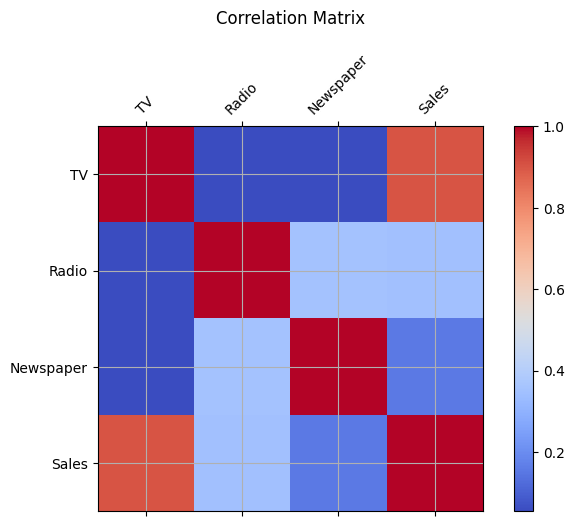

In [13]:
fig, ax = plt.subplots()
cax = ax.matshow(corr_matrix, cmap="coolwarm")
fig.colorbar(cax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()


## Nhận xét / Ý nghĩa
Biểu đồ này trực quan hóa ma trận tương quan bằng màu sắc.

Màu thể hiện mức độ tương quan:
- màu đậm hơn -> tương quan mạnh hơn
- màu nhạt hơn -> tương quan yếu hơn

Khi thuyết trình, biểu đồ này rất hữu ích để cho thấy:
- `TV` có mối quan hệ mạnh nhất với `Sales`
- `Radio` có mối quan hệ dương mức vừa
- `Newspaper` yếu hơn đáng kể


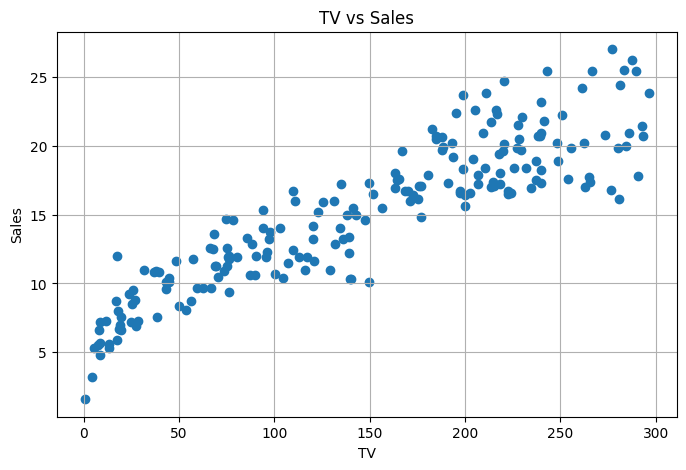

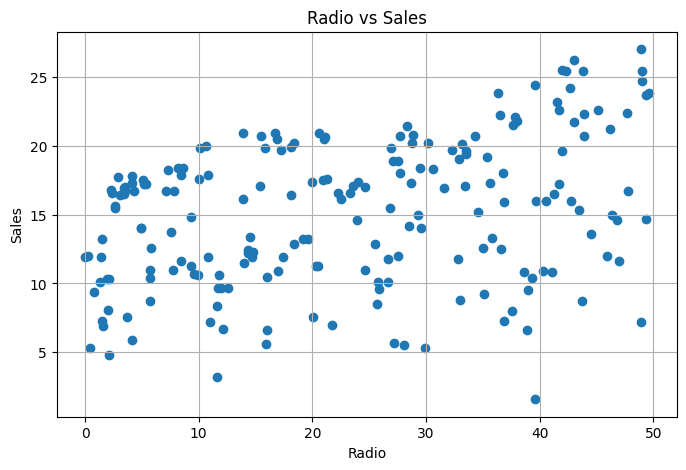

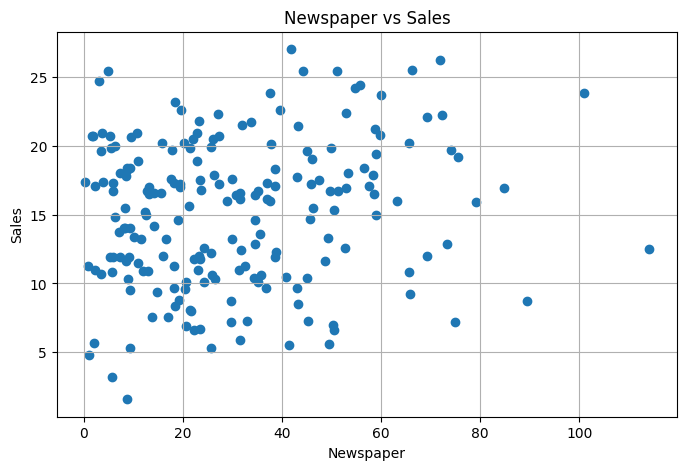

In [14]:
for col in ["TV", "Radio", "Newspaper"]:
    plt.figure()
    plt.scatter(df[col], df["Sales"])
    plt.title(f"{col} vs Sales")
    plt.xlabel(col)
    plt.ylabel("Sales")
    plt.show()


## Nhận xét / Ý nghĩa
Các scatter plot này dùng để quan sát quan hệ giữa từng biến đầu vào và `Sales`.

Cách đọc:
- nếu các điểm đi lên khá rõ -> quan hệ dương mạnh
- nếu điểm phân tán rời rạc -> quan hệ yếu hơn

Thông thường:
- `TV vs Sales` có xu hướng tuyến tính rõ nhất
- `Radio vs Sales` có xu hướng tăng nhưng phân tán hơn
- `Newspaper vs Sales` yếu nhất


In [15]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Number of Outliers": len(outliers)
    }

outlier_summary = pd.DataFrame({col: detect_outliers_iqr(df[col]) for col in df.columns}).T
outlier_summary


,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
TV,74.375,218.825,144.45,-142.300,435.500,0.0
Radio,9.975,36.525,26.55,-29.850,76.350,0.0
Newspaper,12.750,45.100,32.35,-35.775,93.625,2.0
Sales,11.000,19.050,8.05,-1.075,31.125,0.0


## Nhận xét / Ý nghĩa
Cell này phát hiện outliers bằng quy tắc IQR.

Ý nghĩa:
- kiểm tra biến nào có điểm dữ liệu nằm xa phần lớn quan sát
- hỗ trợ giải thích vì sao một số biến có phân phối lệch hơn

Trong dataset này, `Newspaper` thường có nhiều outlier hơn các biến còn lại.


In [16]:
for col in df.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][[col]]

    print(f"\n===== Outliers in {col} =====")
    display(outliers.head(10))
    print("Total outliers:", len(outliers))



===== Outliers in TV =====


,TV


Total outliers: 0

===== Outliers in Radio =====


,Radio


Total outliers: 0

===== Outliers in Newspaper =====


,Newspaper
16,114.0
101,100.9


Total outliers: 2

===== Outliers in Sales =====


,Sales


Total outliers: 0


## Nhận xét / Ý nghĩa
Cell này hiển thị trực tiếp một số giá trị outlier đầu tiên của từng biến.

Mục đích:
- xem cụ thể những giá trị nào bất thường
- hỗ trợ phần mô tả dữ liệu trong báo cáo

Nếu số lượng outlier ít, nhóm có thể giữ nguyên dữ liệu và chỉ ghi chú trong phần EDA.


In [17]:
sales_corr = corr_matrix["Sales"].sort_values(ascending=False)
sales_corr


Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64

## Nhận xét / Ý nghĩa
Cell này sắp xếp mức tương quan của các biến với `Sales`.

Ý nghĩa:
- giúp xác định nhanh biến nào quan trọng nhất về mặt quan hệ tuyến tính
- thuận tiện để đưa vào phần nhận xét ngắn gọn trong slide


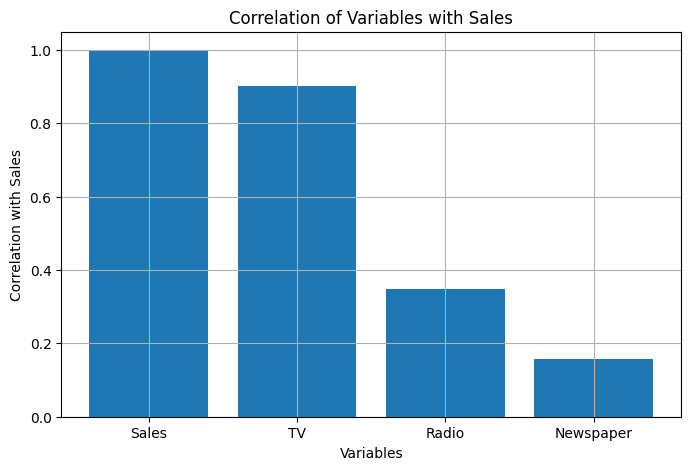

In [18]:
plt.figure()
plt.bar(sales_corr.index, sales_corr.values)
plt.title("Correlation of Variables with Sales")
plt.xlabel("Variables")
plt.ylabel("Correlation with Sales")
plt.show()


## Nhận xét / Ý nghĩa
Biểu đồ cột này giúp trình bày rất trực quan mức độ liên hệ giữa từng biến và `Sales`.

Khi nhìn biểu đồ này, ta thường kết luận:
- `TV` là biến có ảnh hưởng mạnh nhất
- `Radio` đứng thứ hai
- `Newspaper` là biến yếu nhất


# Tóm tắt insight EDA

## Những điểm quan trọng nhất
1. Dataset sạch, không có missing values.
2. Tất cả biến đều là số nên rất thuận lợi cho phân tích.
3. `TV` có độ biến thiên lớn nhất và có tương quan mạnh nhất với `Sales`.
4. `Radio` có mối quan hệ dương với `Sales`, nhưng yếu hơn `TV`.
5. `Newspaper` có phân phối lệch phải và có một số outlier.
6. `Newspaper` có tương quan yếu nhất với `Sales`.
7. Dựa trên EDA, có thể kỳ vọng:
   - mô hình dùng `TV` sẽ khá tốt
   - thêm `Radio` có thể cải thiện kết quả
   - `Newspaper` có thể đóng góp ít hơn

## Câu nhận xét mẫu cho report
Exploratory data analysis shows that the dataset is clean and suitable for linear regression. Among the three advertising channels, TV has the strongest relationship with Sales, followed by Radio, while Newspaper has the weakest relationship and a more right-skewed distribution. Therefore, TV is expected to be the most influential predictor of Sales.
